In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
#import winsound
import scipy.stats as stt
import networkx as nx
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr

import datetime

In [2]:
from sklearn.decomposition import PCA

In [3]:
def pears(x,y):
    return stt.pearsonr(x,y)[0]

def pears_pos(x,y):
    r = stt.pearsonr(x,y)[0]
    if r<0:
        r = 0
    return r

# Correlation which skips the nan (not a number) entries
def corr_nan(x,y):
    x = np.array(x)
    y = np.array(y)
    
    m = np.isnan(x) + np.isnan(y)
    mm = np.logical_not(m)
    
    [r,p] = stt.pearsonr(x[mm],y[mm])
    
    return r

def corr_nan_pos(x,y):
    r = corr_nan(x,y)
    if r<0:
        r = 0
    return r

def corr_dic(x,y,fun=stt.pearsonr): # x and y are two dictionaries
    xx = []
    yy = []
    
    for key in x:
        if key in y:
            xx.append(x[key])
            yy.append(y[key])
        
    return fun(xx,yy)


# Spearman correlation
def spear(x,y):
    return stt.spearmanr(x,y)[0]

def spear_pos(x,y):
    r = spear(x,y)
    if r<0:
        r = 0
    return r

def get_col_values(keys, df):
    
    cols = list()
    
    if type(keys) == type("abc"):
        keys = [keys]
        
    for key in keys:
        col = df[key].values
        cols.append(col)
    
    if len(cols) == 1:
        cols = cols[0]
        
    return cols
        
def check_element_to_remove(to_remove, string):
    main_var = np.nan
    if type(to_remove) == type('sdf'):
        if to_remove in string:
            main_var = True
        else:
            main_var = False
    elif type(to_remove) == type(["a","b"]):
        main_var = False
        for rem in to_remove:
            if rem in string:
                main_var = True
    return main_var


# Maps each dummy-coded response column to the underlying survey item it was
# derived from (see scripts/5_prepare_network.R). Columns not listed here are
# standalone/continuous variables and are treated as their own item.
ITEM_STEM = {
    # data_clean/horizontial_df.csv
    'Russia_trust':            'Russia_trust_item',
    'Russia_distrust':         'Russia_trust_item',
    'Ukraine_trust':           'Ukraine_trust_item',
    'Ukraine_distrust':        'Ukraine_trust_item',
    'Refugee_A':               'Refugee_item',
    'Refugee_D':               'Refugee_item',
    'Refugee_DK':              'Refugee_item',
    'Ukr_EU_A':                'Ukr_EU_item',
    'Ukr_EU_D':                'Ukr_EU_item',
    'Ukr_EU_DK':               'Ukr_EU_item',
    'Defence_Focused':         'Security_FA_item',
    'Normalizaiton_Focused':   'Security_FA_item',
    'Ter_Russia_goals':        'EUI_Ukraine_Outcome_item',
    'Ter_Russia_more':         'EUI_Ukraine_Outcome_item',
    'Ter_pre_war':             'EUI_Ukraine_Outcome_item',
    'Ter_Ukr_gain':            'EUI_Ukraine_Outcome_item',
    'Ter_ukr_retake':          'EUI_Ukraine_Outcome_item',

    # data_clean/vertical_extension.csv
    'Support_aggrandizement':  'Support_Aggrandizement_item',
    'Neutral_aggrandizement':  'Support_Aggrandizement_item',
    'Oppose_aggrandizement':   'Support_Aggrandizement_item',
    'Low_democracy':           'Q5_item',
    'Middle_democracy':        'Q5_item',
    'High_democracy':          'Q5_item',
    'Russia_threat':           'Q68_item',
    'US_threat':               'Q68_item',
    'China_threat':            'Q68_item',
    'Nuclear_threat':          'Q68_item',
    'Other_threat':            'Q68_item',
    'DK_threat':               'Q68_item',
    'EU_punish_nointerference':'Q67_revisions_item',
    'EU_punish_financial':     'Q67_revisions_item',
    'EU_punish_voting':        'Q67_revisions_item',
    'EU_punish_other':         'Q67_revisions_item',
    'Econ_better_off':         'Econ_comparison_item',
    'Econ_the_same':           'Econ_comparison_item',
    'Econ_worse_off':          'Econ_comparison_item',
    'Econ_DK':                 'Econ_comparison_item',
     'Trust_EU' : 'EU_trust_item',
         'Do_not_trust_EU' : 'EU_trust_item',
         'Trust_Gov': 'Gov_trust_item',
         'Do_not_trust_Gov' : 'Gov_trust_item',
          'General_trust_trust' : 'Gen_trust_item',
          'General_trust_notrust' : 'Gen_trust_item',

}

def get_item_stem(node_name):
    return ITEM_STEM.get(node_name, node_name)


def make_graph_(df, list_of_nodes, metrics, exclude_same_question=True, print_=False, remove_name=''):
    G = nx.Graph()
    
    if remove_name == '': # should we remove some elements
        remove_el = False
    else:
        remove_el = True
    
    for i, node_i in enumerate(list_of_nodes):
        
        if remove_el and (check_element_to_remove(remove_name, node_i)):# this is one of the elements to remove
            if print_:
                print("Skipping : ", node_i)
        else:
            for j, node_j in enumerate(list_of_nodes):

                if remove_el and (check_element_to_remove(remove_name, node_j)):
                    if print_:
                        print("Skipping : ", node_i)
                    
                else:
                    if print_:
                        n_tot = len(list_of_nodes)**2
                        current = (i*len(list_of_nodes))+(j)
                        print(current,"/",n_tot, " = ", np.round(current/n_tot,decimals=2))

                    if j <= i:
                        continue

                    if exclude_same_question:
                        if get_item_stem(node_i) == get_item_stem(node_j):
                            # responses belonging to the same underlying survey item
                            # are mutually exclusive and carry no information, so we
                            # don't compute a correlation between them (see ResIN,
                            # Carpentras et al. 2024, https://doi.org/10.1057/s41599-024-03037-x)
                            continue

                    [c1,c2] = get_col_values([node_i,node_j], df)
                    weight = metrics(c1,c2)
                    G.add_weighted_edges_from([(node_i,node_j,weight)])
    return G



In [10]:
df_2022 = pd.read_csv("data_clean/horizontial_df2022.csv")
df_2023 = pd.read_csv("data_clean/horizontial_df2023.csv")
df_2024 = pd.read_csv("data_clean/horizontial_df2024.csv")
df_2025 = pd.read_csv("data_clean/horizontial_df2025.csv")
df = pd.read_csv("data_clean/horizontial_df.csv")

In [5]:
avg_corr = 0
n = 0
for i1, col1 in enumerate(df):
    for i2, col2 in enumerate(df):
        if i1 > i2:
            c1 = df[col1]
            c2 = df[col2]

            r = stt.pearsonr(c1,c2)[0]
            r_ = np.abs(r)
            
            n += 1
            avg_corr = ((n-1)*avg_corr + r_)/n

#             print(r_)
print(avg_corr)

0.21205052441973266


In [11]:
from adjustText import adjust_text
from scipy.stats import pearsonr


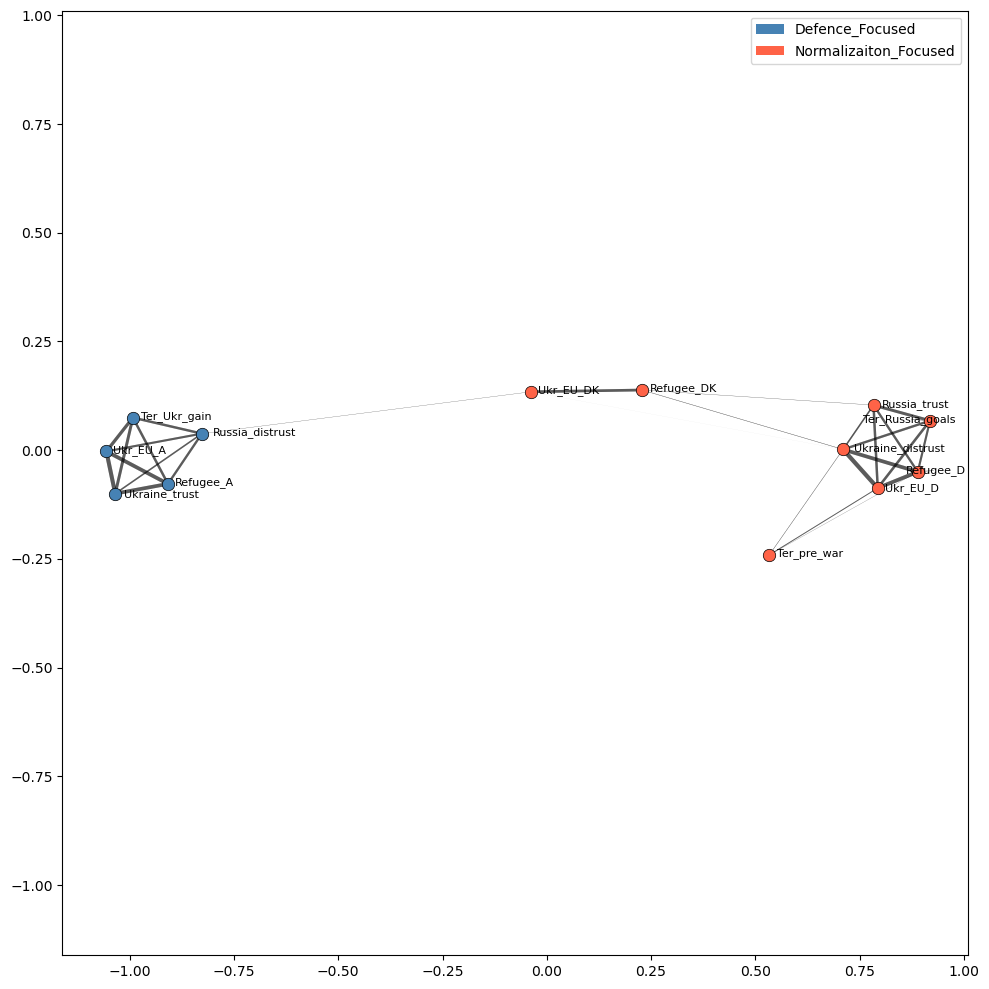

In [12]:
# ── 0. Setup ──────────────────────────────────────────────────────────────
fa_nodes  = ['Defence_Focused', 'Normalizaiton_Focused']
fa_colors = {
    'Defence_Focused':       'steelblue',
    'Normalizaiton_Focused': 'tomato'
}

# ── 1. Build graph (FA nodes excluded) ────────────────────────────────────
list_of_nodes = [c for c in df.columns if c not in fa_nodes and c != 'Unnamed: 0']
G = make_graph_(df, list_of_nodes, pears_pos, exclude_same_question=True)

# ── 2. Layout + PCA ───────────────────────────────────────────────────────
pos = nx.spring_layout(G, iterations=50000*10, seed=1998)

pos3     = []
key_list = []
for key in pos:
    pos3.append([pos[key][0], pos[key][1]])
    key_list.append(key)

pca   = PCA(n_components=2)
x_pca = pca.fit_transform(pos3)
xx    = x_pca[:, 0]
yy    = x_pca[:, 1]
mm    = min(xx) * 1.1
MM    = max(xx) * 1.1

# ── 3. FA node attributes + colours ───────────────────────────────────────
for fa in fa_nodes:
    dic_ = {node: pearsonr(df[node], df[fa])[0] for node in G.nodes}
    nx.set_node_attributes(G, dic_, fa)

nx.write_gexf(G,'data_clean/horizontial_coherence_network.gexf')

node_colors = {}
for node in G.nodes:
    correlations = {fa: pearsonr(df[node], df[fa])[0] for fa in fa_nodes}
    dominant_fa  = max(correlations, key=correlations.get)
    node_colors[node] = fa_colors[dominant_fa]

# ── 4. Plot ───────────────────────────────────────────────────────────────
koef = 3
plt.figure(figsize=(10, 10))

# Edges
weights = [d['weight'] for u, v, d in G.edges(data=True) if d['weight'] > 0]
w_min, w_max = min(weights), max(weights)

for i1, key1 in enumerate(key_list):
    for i2, key2 in enumerate(key_list):
        if (key1, key2) in G.edges:
            w = G.get_edge_data(key1, key2)['weight']
            if w > 0.:
                w_scaled = (w - w_min) / (w_max - w_min)
                plt.plot(
                    [xx[i1], xx[i2]], [yy[i1], yy[i2]],
                    color='k', linewidth=koef * w_scaled,
                    alpha=0.4, zorder=1
                )

# Nodes + labels
texts = []
for i, key in enumerate(key_list):
    plt.scatter(xx[i], yy[i], s=80,
                c=node_colors[key], zorder=2,
                edgecolors='k', linewidths=0.5)
    texts.append(plt.text(xx[i], yy[i], key, fontsize=8))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=fa) for fa, c in fa_colors.items()]
plt.legend(handles=legend_elements, loc='best')

plt.xlim([mm, MM])
plt.ylim([mm, MM])
plt.tight_layout()
plt.show()

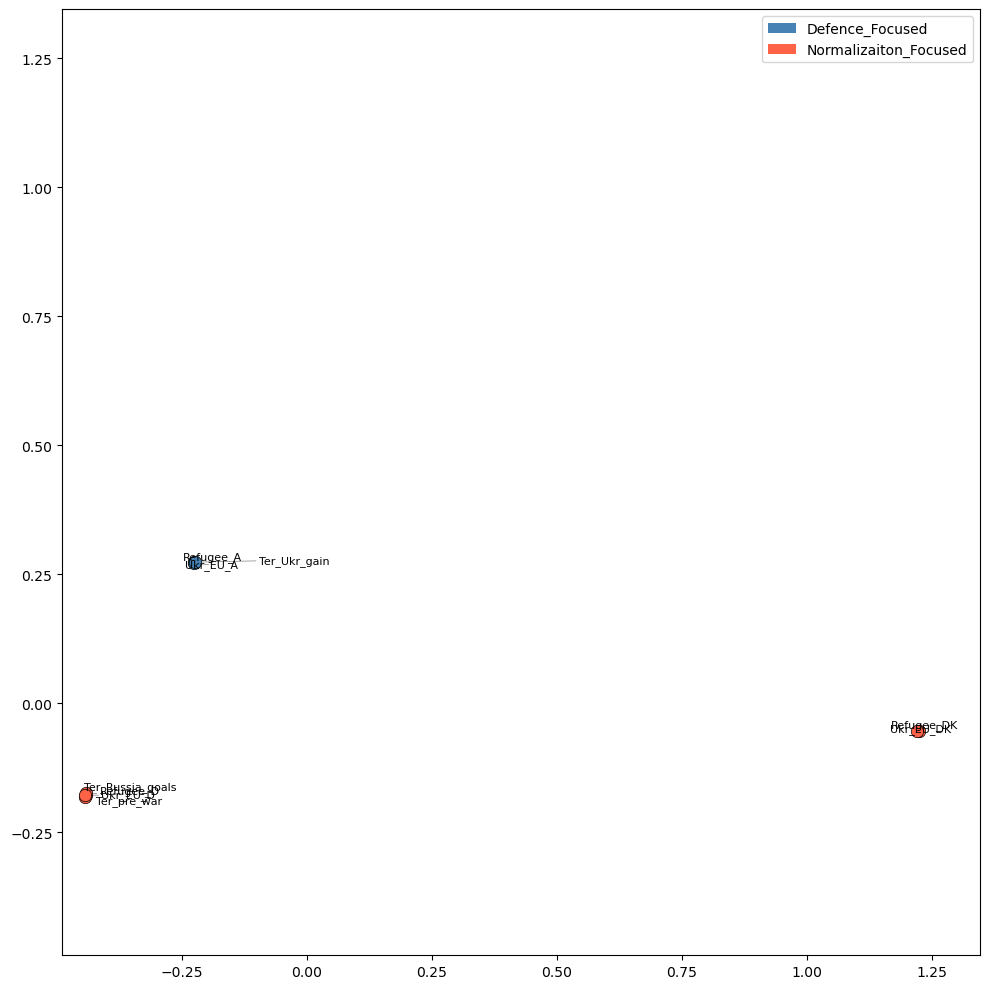

In [13]:
# ── 0. Setup ──────────────────────────────────────────────────────────────
fa_nodes  = ['Defence_Focused', 'Normalizaiton_Focused']
fa_colors = {
    'Defence_Focused':       'steelblue',
    'Normalizaiton_Focused': 'tomato'
}

# ── 1. Build graph (FA nodes excluded) ────────────────────────────────────
list_of_nodes = [c for c in df_2023.columns if c not in fa_nodes and c != 'Unnamed: 0']
G = make_graph_(df_2023, list_of_nodes, pears_pos, exclude_same_question=True)

# ── 2. Layout + PCA ───────────────────────────────────────────────────────
pos = nx.spring_layout(G, iterations=50000*10, seed=1998)

pos3     = []
key_list = []
for key in pos:
    pos3.append([pos[key][0], pos[key][1]])
    key_list.append(key)

pca   = PCA(n_components=2)
x_pca = pca.fit_transform(pos3)
xx    = x_pca[:, 0]
yy    = x_pca[:, 1]
mm    = min(xx) * 1.1
MM    = max(xx) * 1.1

# ── 3. FA node attributes + colours ───────────────────────────────────────
for fa in fa_nodes:
    dic_ = {node: pearsonr(df_2023[node], df_2023[fa])[0] for node in G.nodes}
    nx.set_node_attributes(G, dic_, fa)

nx.write_gexf(G,'data_clean/horizontial_coherence_network2023.gexf')

node_colors = {}
for node in G.nodes:
    correlations = {fa: pearsonr(df_2023[node], df_2023[fa])[0] for fa in fa_nodes}
    dominant_fa  = max(correlations, key=correlations.get)
    node_colors[node] = fa_colors[dominant_fa]

# ── 4. Plot ───────────────────────────────────────────────────────────────
koef = 3
plt.figure(figsize=(10, 10))

# Edges
weights = [d['weight'] for u, v, d in G.edges(data=True) if d['weight'] > 0]
w_min, w_max = min(weights), max(weights)

for i1, key1 in enumerate(key_list):
    for i2, key2 in enumerate(key_list):
        if (key1, key2) in G.edges:
            w = G.get_edge_data(key1, key2)['weight']
            if w > 0.:
                w_scaled = (w - w_min) / (w_max - w_min)
                plt.plot(
                    [xx[i1], xx[i2]], [yy[i1], yy[i2]],
                    color='k', linewidth=koef * w_scaled,
                    alpha=0.4, zorder=1
                )

# Nodes + labels
texts = []
for i, key in enumerate(key_list):
    plt.scatter(xx[i], yy[i], s=80,
                c=node_colors[key], zorder=2,
                edgecolors='k', linewidths=0.5)
    texts.append(plt.text(xx[i], yy[i], key, fontsize=8))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=fa) for fa, c in fa_colors.items()]
plt.legend(handles=legend_elements, loc='best')

plt.xlim([mm, MM])
plt.ylim([mm, MM])
plt.tight_layout()
plt.show()

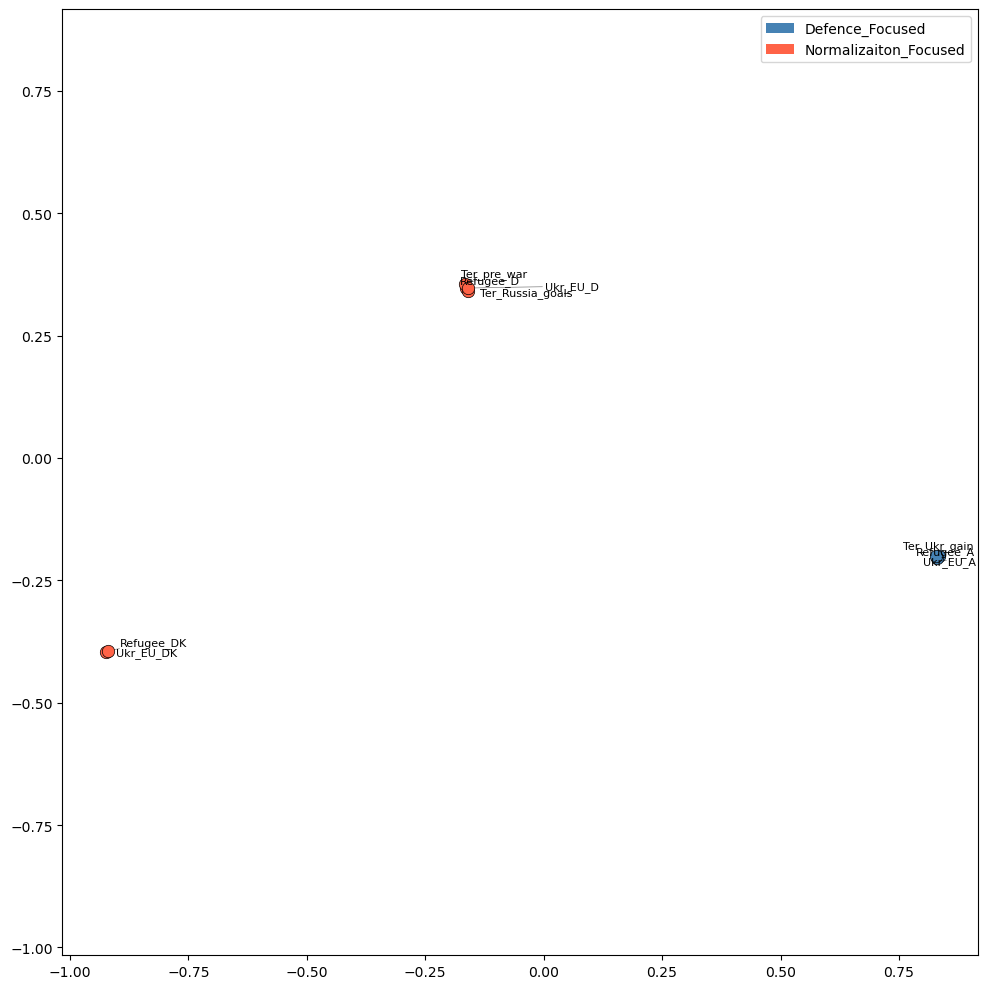

In [14]:
# ── 0. Setup ──────────────────────────────────────────────────────────────
fa_nodes  = ['Defence_Focused', 'Normalizaiton_Focused']
fa_colors = {
    'Defence_Focused':       'steelblue',
    'Normalizaiton_Focused': 'tomato'
}

# ── 1. Build graph (FA nodes excluded) ────────────────────────────────────
list_of_nodes = [c for c in df_2024.columns if c not in fa_nodes and c != 'Unnamed: 0']
G = make_graph_(df_2024, list_of_nodes, pears_pos, exclude_same_question=True)

# ── 2. Layout + PCA ───────────────────────────────────────────────────────
pos = nx.spring_layout(G, iterations=50000*10, seed=1998)

pos3     = []
key_list = []
for key in pos:
    pos3.append([pos[key][0], pos[key][1]])
    key_list.append(key)

pca   = PCA(n_components=2)
x_pca = pca.fit_transform(pos3)
xx    = x_pca[:, 0]
yy    = x_pca[:, 1]
mm    = min(xx) * 1.1
MM    = max(xx) * 1.1

# ── 3. FA node attributes + colours ───────────────────────────────────────
for fa in fa_nodes:
    dic_ = {node: pearsonr(df_2024[node], df_2024[fa])[0] for node in G.nodes}
    nx.set_node_attributes(G, dic_, fa)

nx.write_gexf(G,'data_clean/horizontial_coherence_network2024.gexf')

node_colors = {}
for node in G.nodes:
    correlations = {fa: pearsonr(df_2024[node], df_2024[fa])[0] for fa in fa_nodes}
    dominant_fa  = max(correlations, key=correlations.get)
    node_colors[node] = fa_colors[dominant_fa]

# ── 4. Plot ───────────────────────────────────────────────────────────────
koef = 3
plt.figure(figsize=(10, 10))

# Edges
weights = [d['weight'] for u, v, d in G.edges(data=True) if d['weight'] > 0]
w_min, w_max = min(weights), max(weights)

for i1, key1 in enumerate(key_list):
    for i2, key2 in enumerate(key_list):
        if (key1, key2) in G.edges:
            w = G.get_edge_data(key1, key2)['weight']
            if w > 0.:
                w_scaled = (w - w_min) / (w_max - w_min)
                plt.plot(
                    [xx[i1], xx[i2]], [yy[i1], yy[i2]],
                    color='k', linewidth=koef * w_scaled,
                    alpha=0.4, zorder=1
                )

# Nodes + labels
texts = []
for i, key in enumerate(key_list):
    plt.scatter(xx[i], yy[i], s=80,
                c=node_colors[key], zorder=2,
                edgecolors='k', linewidths=0.5)
    texts.append(plt.text(xx[i], yy[i], key, fontsize=8))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=fa) for fa, c in fa_colors.items()]
plt.legend(handles=legend_elements, loc='best')

plt.xlim([mm, MM])
plt.ylim([mm, MM])
plt.tight_layout()
plt.show()

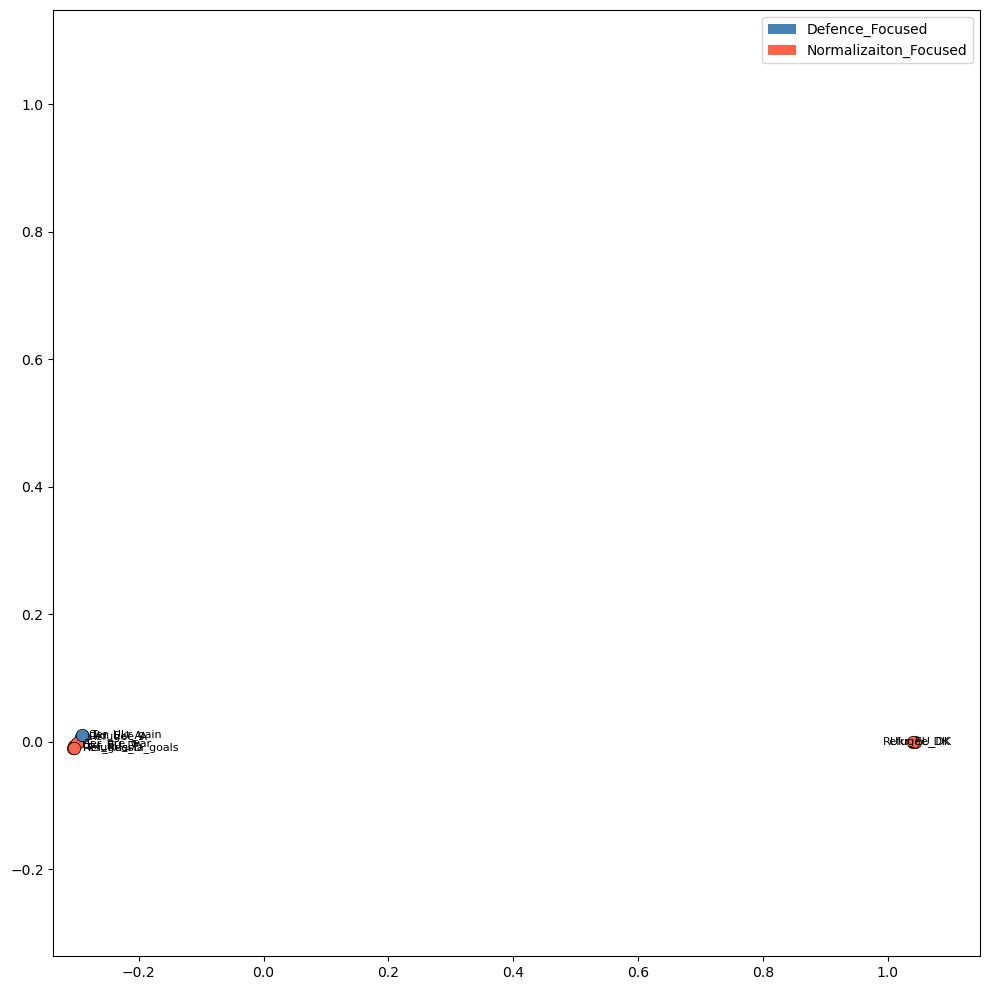

In [15]:
# ── 0. Setup ──────────────────────────────────────────────────────────────
fa_nodes  = ['Defence_Focused', 'Normalizaiton_Focused']
fa_colors = {
    'Defence_Focused':       'steelblue',
    'Normalizaiton_Focused': 'tomato'
}

# ── 1. Build graph (FA nodes excluded) ────────────────────────────────────
list_of_nodes = [c for c in df_2025.columns if c not in fa_nodes and c != 'Unnamed: 0']
G = make_graph_(df_2025, list_of_nodes, pears_pos, exclude_same_question=True)

# ── 2. Layout + PCA ───────────────────────────────────────────────────────
pos = nx.spring_layout(G, iterations=50000*10, seed=1998)

pos3     = []
key_list = []
for key in pos:
    pos3.append([pos[key][0], pos[key][1]])
    key_list.append(key)

pca   = PCA(n_components=2)
x_pca = pca.fit_transform(pos3)
xx    = x_pca[:, 0]
yy    = x_pca[:, 1]
mm    = min(xx) * 1.1
MM    = max(xx) * 1.1

# ── 3. FA node attributes + colours ───────────────────────────────────────
for fa in fa_nodes:
    dic_ = {node: pearsonr(df_2025[node], df_2025[fa])[0] for node in G.nodes}
    nx.set_node_attributes(G, dic_, fa)

nx.write_gexf(G,'data_clean/horizontial_coherence_network2025.gexf')

node_colors = {}
for node in G.nodes:
    correlations = {fa: pearsonr(df_2025[node], df_2025[fa])[0] for fa in fa_nodes}
    dominant_fa  = max(correlations, key=correlations.get)
    node_colors[node] = fa_colors[dominant_fa]

# ── 4. Plot ───────────────────────────────────────────────────────────────
koef = 3
plt.figure(figsize=(10, 10))

# Edges
weights = [d['weight'] for u, v, d in G.edges(data=True) if d['weight'] > 0]
w_min, w_max = min(weights), max(weights)

for i1, key1 in enumerate(key_list):
    for i2, key2 in enumerate(key_list):
        if (key1, key2) in G.edges:
            w = G.get_edge_data(key1, key2)['weight']
            if w > 0.:
                w_scaled = (w - w_min) / (w_max - w_min)
                plt.plot(
                    [xx[i1], xx[i2]], [yy[i1], yy[i2]],
                    color='k', linewidth=koef * w_scaled,
                    alpha=0.4, zorder=1
                )

# Nodes + labels
texts = []
for i, key in enumerate(key_list):
    plt.scatter(xx[i], yy[i], s=80,
                c=node_colors[key], zorder=2,
                edgecolors='k', linewidths=0.5)
    texts.append(plt.text(xx[i], yy[i], key, fontsize=8))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=fa) for fa, c in fa_colors.items()]
plt.legend(handles=legend_elements, loc='best')

plt.xlim([mm, MM])
plt.ylim([mm, MM])
plt.tight_layout()
plt.show()

In [16]:
df2_2022 = pd.read_csv("data_clean/vertical_extension2022.csv")
df2_2023 = pd.read_csv("data_clean/vertical_extension2023.csv")
df2_2024 = pd.read_csv("data_clean/vertical_extension2024.csv")
df2_2025 = pd.read_csv("data_clean/vertical_extension2025.csv")
df2 = pd.read_csv("data_clean/vertical_extension.csv")

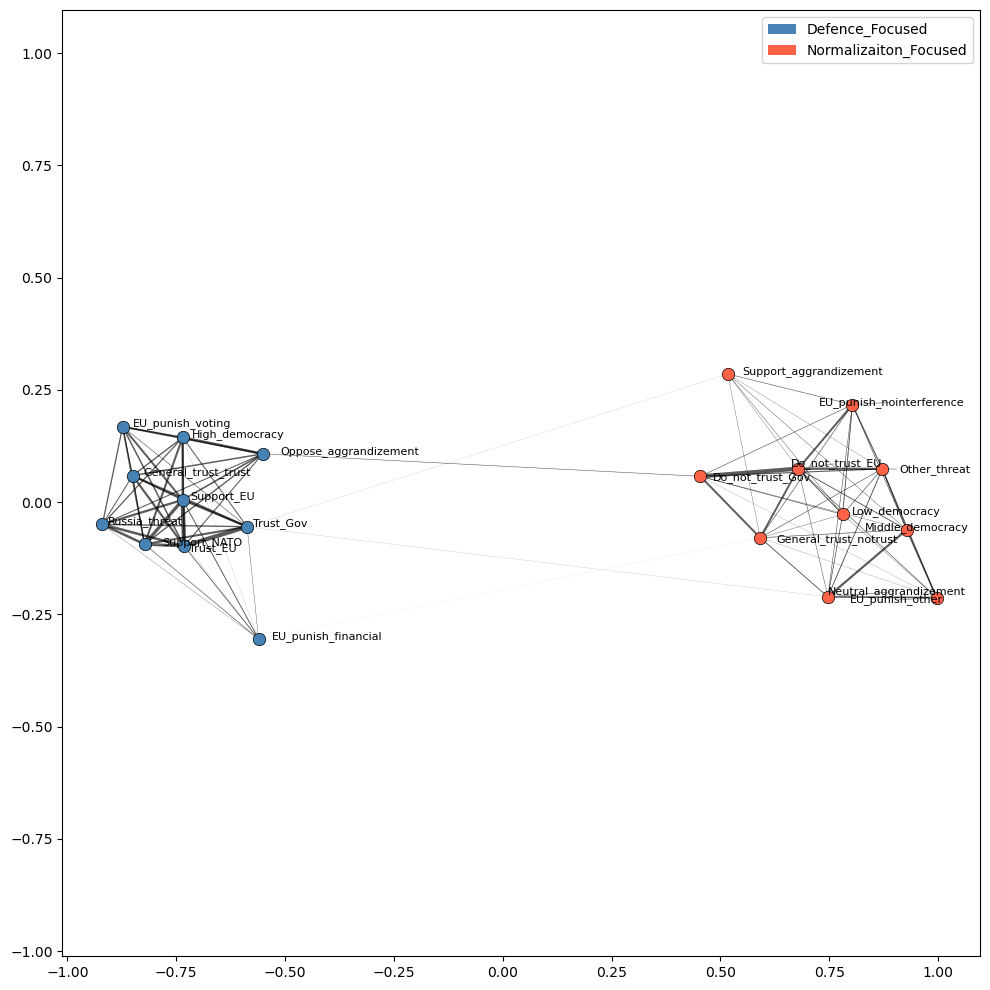

In [17]:
# ── 0. Setup ──────────────────────────────────────────────────────────────
fa_nodes  = ['Defence_Focused', 'Normalizaiton_Focused']
fa_colors = {
    'Defence_Focused':       'steelblue',
    'Normalizaiton_Focused': 'tomato'
}

# ── 1. Build graph (FA nodes excluded) ────────────────────────────────────
list_of_nodes = [c for c in df2.columns if c not in fa_nodes and c != 'Unnamed: 0']
G = make_graph_(df2, list_of_nodes, pears_pos, exclude_same_question=True)

# ── 2. Layout + PCA ───────────────────────────────────────────────────────
pos = nx.spring_layout(G, iterations=50000*10, seed=1998)

pos3     = []
key_list = []
for key in pos:
    pos3.append([pos[key][0], pos[key][1]])
    key_list.append(key)

pca   = PCA(n_components=2)
x_pca = pca.fit_transform(pos3)
xx    = x_pca[:, 0]
yy    = x_pca[:, 1]
mm    = min(xx) * 1.1
MM    = max(xx) * 1.1

# ── 3. FA node attributes + colours ───────────────────────────────────────
for fa in fa_nodes:
    dic_ = {node: pearsonr(df2[node], df2[fa])[0] for node in G.nodes}
    nx.set_node_attributes(G, dic_, fa)

nx.write_gexf(G,'data_clean/vertical_extension_network.gexf')

node_colors = {}
for node in G.nodes:
    correlations = {fa: pearsonr(df2[node], df2[fa])[0] for fa in fa_nodes}
    dominant_fa  = max(correlations, key=correlations.get)
    node_colors[node] = fa_colors[dominant_fa]

# ── 4. Plot ───────────────────────────────────────────────────────────────
koef = 3
plt.figure(figsize=(10, 10))

# Edges
weights = [d['weight'] for u, v, d in G.edges(data=True) if d['weight'] > 0]
w_min, w_max = min(weights), max(weights)

for i1, key1 in enumerate(key_list):
    for i2, key2 in enumerate(key_list):
        if (key1, key2) in G.edges:
            w = G.get_edge_data(key1, key2)['weight']
            if w > 0.:
                w_scaled = (w - w_min) / (w_max - w_min)
                plt.plot(
                    [xx[i1], xx[i2]], [yy[i1], yy[i2]],
                    color='k', linewidth=koef * w_scaled,
                    alpha=0.4, zorder=1
                )

# Nodes + labels
texts = []
for i, key in enumerate(key_list):
    plt.scatter(xx[i], yy[i], s=80,
                c=node_colors[key], zorder=2,
                edgecolors='k', linewidths=0.5)
    texts.append(plt.text(xx[i], yy[i], key, fontsize=8))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=fa) for fa, c in fa_colors.items()]
plt.legend(handles=legend_elements, loc='best')

plt.xlim([mm, MM])
plt.ylim([mm, MM])
plt.tight_layout()
plt.show()

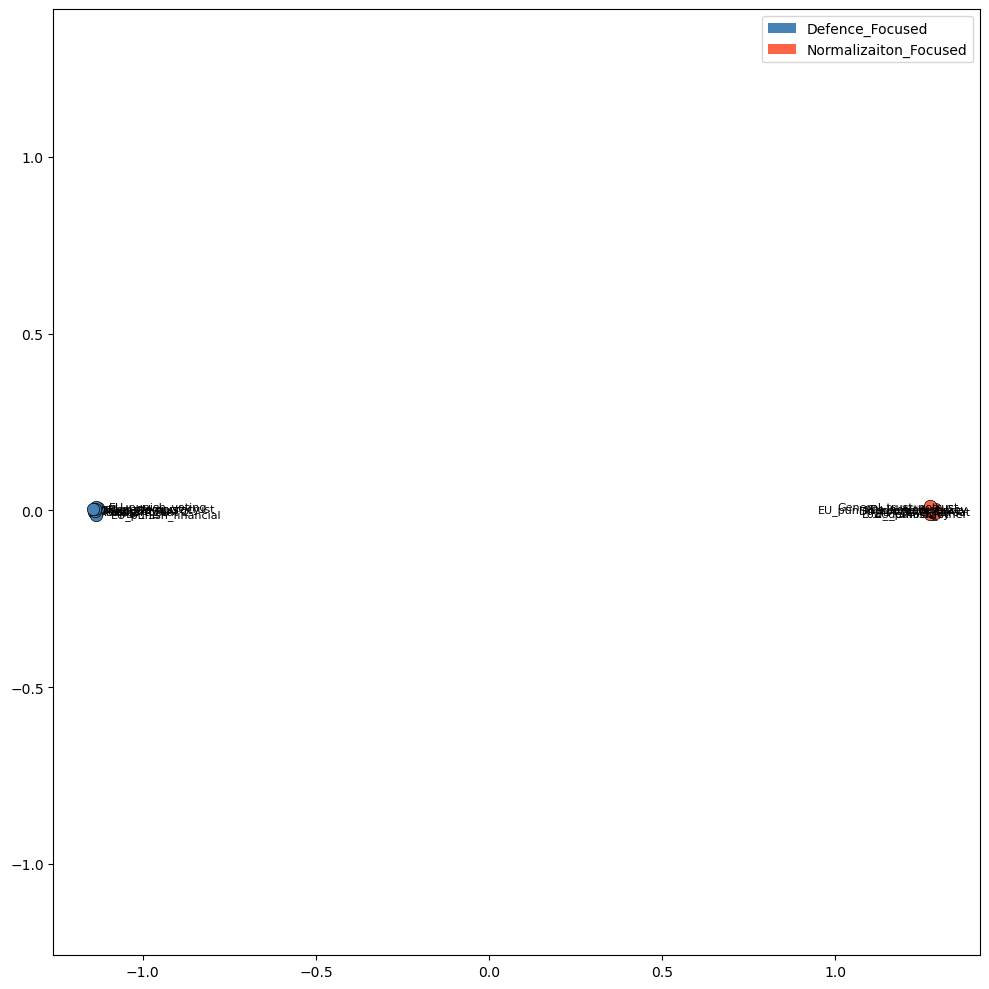

In [36]:
# ── 0. Setup ──────────────────────────────────────────────────────────────
fa_nodes  = ['Defence_Focused', 'Normalizaiton_Focused']
fa_colors = {
    'Defence_Focused':       'steelblue',
    'Normalizaiton_Focused': 'tomato'
}

# ── 1. Build graph (FA nodes excluded) ────────────────────────────────────
list_of_nodes = [c for c in df2_2022.columns if c not in fa_nodes and c != 'Unnamed: 0']
G = make_graph_(df2_2022, list_of_nodes, pears_pos, exclude_same_question=True)

# ── 2. Layout + PCA ───────────────────────────────────────────────────────
pos = nx.spring_layout(G, iterations=50000*10, seed=1998)

pos3     = []
key_list = []
for key in pos:
    pos3.append([pos[key][0], pos[key][1]])
    key_list.append(key)

pca   = PCA(n_components=2)
x_pca = pca.fit_transform(pos3)
xx    = x_pca[:, 0]
yy    = x_pca[:, 1]
mm    = min(xx) * 1.1
MM    = max(xx) * 1.1

# ── 3. FA node attributes + colours ───────────────────────────────────────
for fa in fa_nodes:
    dic_ = {node: pearsonr(df2_2022[node], df2_2022[fa])[0] for node in G.nodes}
    nx.set_node_attributes(G, dic_, fa)

nx.write_gexf(G,'data_clean/vertical_extension_network_2022.gexf')

node_colors = {}
for node in G.nodes:
    correlations = {fa: pearsonr(df2_2022[node], df2_2022[fa])[0] for fa in fa_nodes}
    dominant_fa  = max(correlations, key=correlations.get)
    node_colors[node] = fa_colors[dominant_fa]

# ── 4. Plot ───────────────────────────────────────────────────────────────
koef = 3
plt.figure(figsize=(10, 10))

# Edges
weights = [d['weight'] for u, v, d in G.edges(data=True) if d['weight'] > 0]
w_min, w_max = min(weights), max(weights)

for i1, key1 in enumerate(key_list):
    for i2, key2 in enumerate(key_list):
        if (key1, key2) in G.edges:
            w = G.get_edge_data(key1, key2)['weight']
            if w > 0.:
                w_scaled = (w - w_min) / (w_max - w_min)
                plt.plot(
                    [xx[i1], xx[i2]], [yy[i1], yy[i2]],
                    color='k', linewidth=koef * w_scaled,
                    alpha=0.4, zorder=1
                )

# Nodes + labels
texts = []
for i, key in enumerate(key_list):
    plt.scatter(xx[i], yy[i], s=80,
                c=node_colors[key], zorder=2,
                edgecolors='k', linewidths=0.5)
    texts.append(plt.text(xx[i], yy[i], key, fontsize=8))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=fa) for fa, c in fa_colors.items()]
plt.legend(handles=legend_elements, loc='best')

plt.xlim([mm, MM])
plt.ylim([mm, MM])
plt.tight_layout()
plt.show()

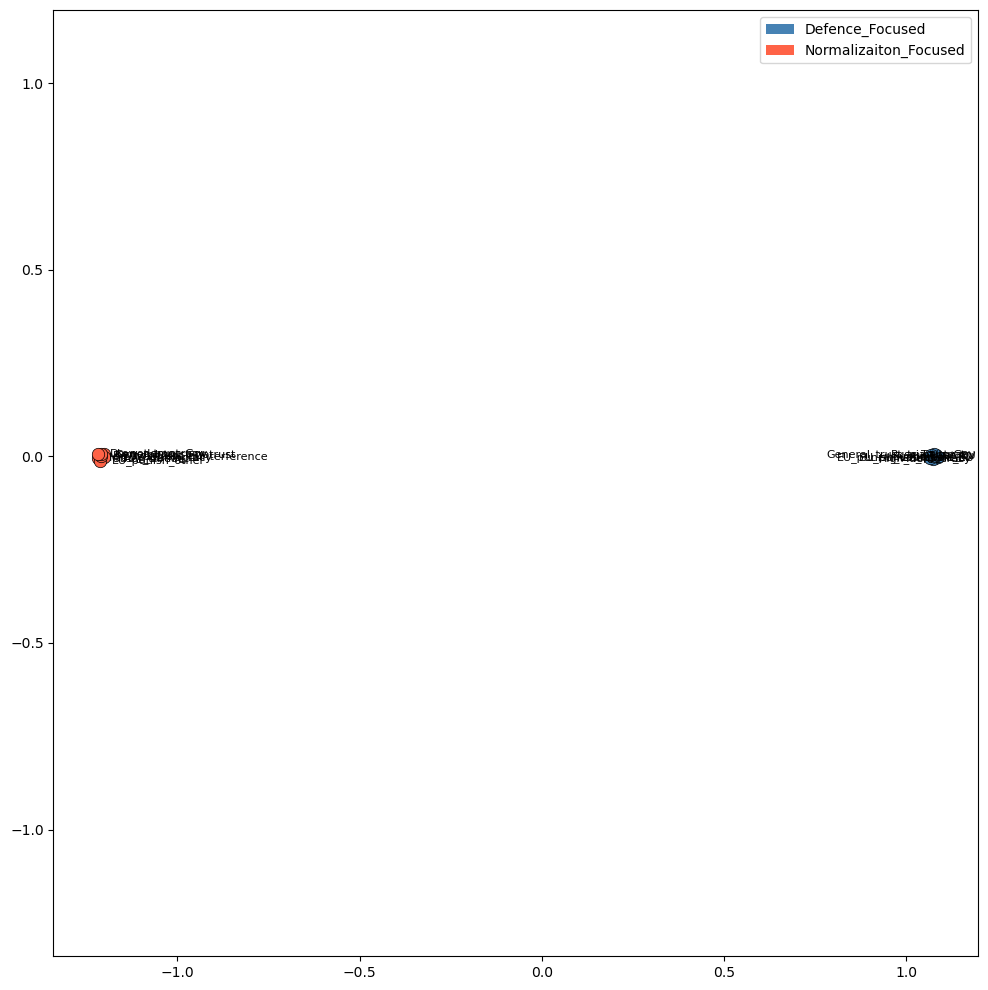

In [38]:
# ── 0. Setup ──────────────────────────────────────────────────────────────
fa_nodes  = ['Defence_Focused', 'Normalizaiton_Focused']
fa_colors = {
    'Defence_Focused':       'steelblue',
    'Normalizaiton_Focused': 'tomato'
}

# ── 1. Build graph (FA nodes excluded) ────────────────────────────────────
list_of_nodes = [c for c in df2_2023.columns if c not in fa_nodes and c != 'Unnamed: 0']
G = make_graph_(df2_2023, list_of_nodes, pears_pos, exclude_same_question=True)

# ── 2. Layout + PCA ───────────────────────────────────────────────────────
pos = nx.spring_layout(G, iterations=50000*10, seed=1998)

pos3     = []
key_list = []
for key in pos:
    pos3.append([pos[key][0], pos[key][1]])
    key_list.append(key)

pca   = PCA(n_components=2)
x_pca = pca.fit_transform(pos3)
xx    = x_pca[:, 0]
yy    = x_pca[:, 1]
mm    = min(xx) * 1.1
MM    = max(xx) * 1.1

# ── 3. FA node attributes + colours ───────────────────────────────────────
for fa in fa_nodes:
    dic_ = {node: pearsonr(df2_2023[node], df2_2023[fa])[0] for node in G.nodes}
    nx.set_node_attributes(G, dic_, fa)

nx.write_gexf(G,'data_clean/vertical_extension_network_2023.gexf')

node_colors = {}
for node in G.nodes:
    correlations = {fa: pearsonr(df2_2023[node], df2_2023[fa])[0] for fa in fa_nodes}
    dominant_fa  = max(correlations, key=correlations.get)
    node_colors[node] = fa_colors[dominant_fa]

# ── 4. Plot ───────────────────────────────────────────────────────────────
koef = 3
plt.figure(figsize=(10, 10))

# Edges
weights = [d['weight'] for u, v, d in G.edges(data=True) if d['weight'] > 0]
w_min, w_max = min(weights), max(weights)

for i1, key1 in enumerate(key_list):
    for i2, key2 in enumerate(key_list):
        if (key1, key2) in G.edges:
            w = G.get_edge_data(key1, key2)['weight']
            if w > 0.:
                w_scaled = (w - w_min) / (w_max - w_min)
                plt.plot(
                    [xx[i1], xx[i2]], [yy[i1], yy[i2]],
                    color='k', linewidth=koef * w_scaled,
                    alpha=0.4, zorder=1
                )

# Nodes + labels
texts = []
for i, key in enumerate(key_list):
    plt.scatter(xx[i], yy[i], s=80,
                c=node_colors[key], zorder=2,
                edgecolors='k', linewidths=0.5)
    texts.append(plt.text(xx[i], yy[i], key, fontsize=8))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=fa) for fa, c in fa_colors.items()]
plt.legend(handles=legend_elements, loc='best')

plt.xlim([mm, MM])
plt.ylim([mm, MM])
plt.tight_layout()
plt.show()

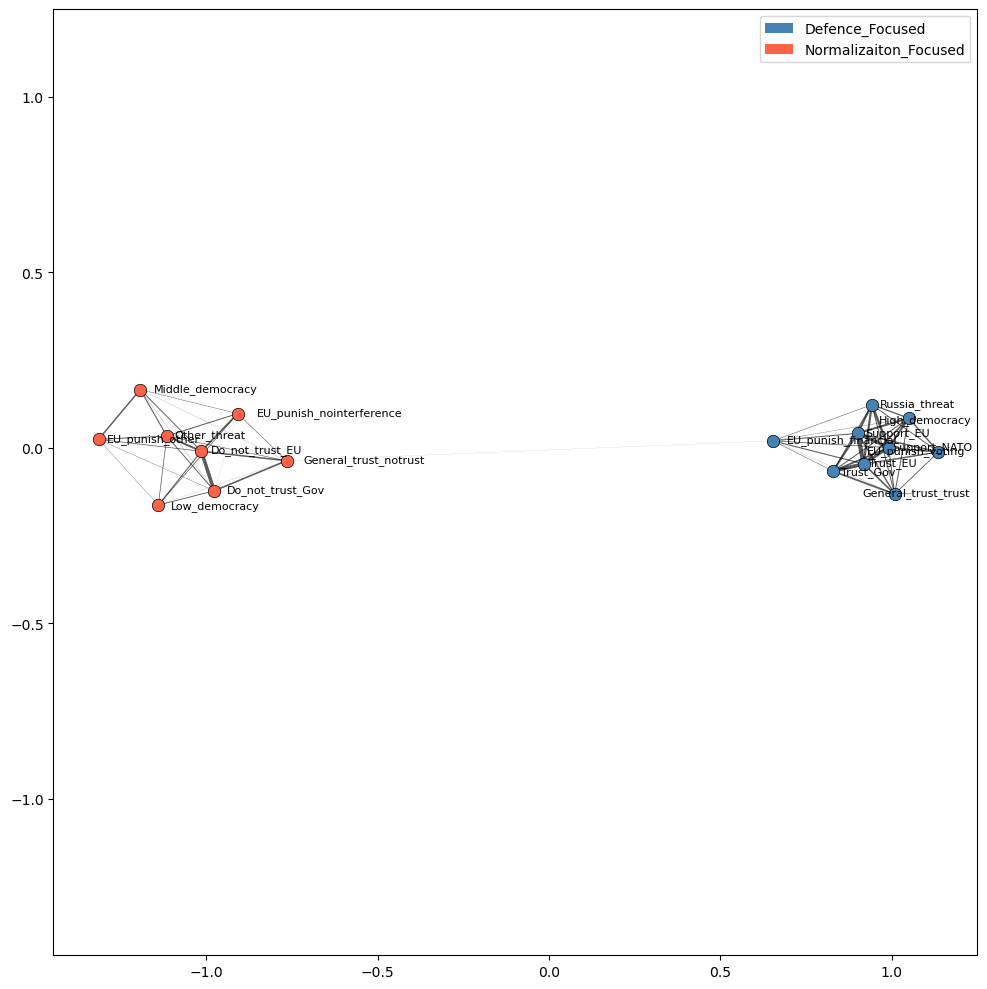

In [39]:
# ── 0. Setup ──────────────────────────────────────────────────────────────
fa_nodes  = ['Defence_Focused', 'Normalizaiton_Focused']
fa_colors = {
    'Defence_Focused':       'steelblue',
    'Normalizaiton_Focused': 'tomato'
}

# ── 1. Build graph (FA nodes excluded) ────────────────────────────────────
list_of_nodes = [c for c in df2_2024.columns if c not in fa_nodes and c != 'Unnamed: 0']
G = make_graph_(df2_2024, list_of_nodes, pears_pos, exclude_same_question=True)

# ── 2. Layout + PCA ───────────────────────────────────────────────────────
pos = nx.spring_layout(G, iterations=50000*10, seed=1998)

pos3     = []
key_list = []
for key in pos:
    pos3.append([pos[key][0], pos[key][1]])
    key_list.append(key)

pca   = PCA(n_components=2)
x_pca = pca.fit_transform(pos3)
xx    = x_pca[:, 0]
yy    = x_pca[:, 1]
mm    = min(xx) * 1.1
MM    = max(xx) * 1.1

# ── 3. FA node attributes + colours ───────────────────────────────────────
for fa in fa_nodes:
    dic_ = {node: pearsonr(df2_2024[node], df2_2024[fa])[0] for node in G.nodes}
    nx.set_node_attributes(G, dic_, fa)

nx.write_gexf(G,'data_clean/vertical_extension_network_2024.gexf')

node_colors = {}
for node in G.nodes:
    correlations = {fa: pearsonr(df2_2024[node], df2_2024[fa])[0] for fa in fa_nodes}
    dominant_fa  = max(correlations, key=correlations.get)
    node_colors[node] = fa_colors[dominant_fa]

# ── 4. Plot ───────────────────────────────────────────────────────────────
koef = 3
plt.figure(figsize=(10, 10))

# Edges
weights = [d['weight'] for u, v, d in G.edges(data=True) if d['weight'] > 0]
w_min, w_max = min(weights), max(weights)

for i1, key1 in enumerate(key_list):
    for i2, key2 in enumerate(key_list):
        if (key1, key2) in G.edges:
            w = G.get_edge_data(key1, key2)['weight']
            if w > 0.:
                w_scaled = (w - w_min) / (w_max - w_min)
                plt.plot(
                    [xx[i1], xx[i2]], [yy[i1], yy[i2]],
                    color='k', linewidth=koef * w_scaled,
                    alpha=0.4, zorder=1
                )

# Nodes + labels
texts = []
for i, key in enumerate(key_list):
    plt.scatter(xx[i], yy[i], s=80,
                c=node_colors[key], zorder=2,
                edgecolors='k', linewidths=0.5)
    texts.append(plt.text(xx[i], yy[i], key, fontsize=8))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=fa) for fa, c in fa_colors.items()]
plt.legend(handles=legend_elements, loc='best')

plt.xlim([mm, MM])
plt.ylim([mm, MM])
plt.tight_layout()
plt.show()

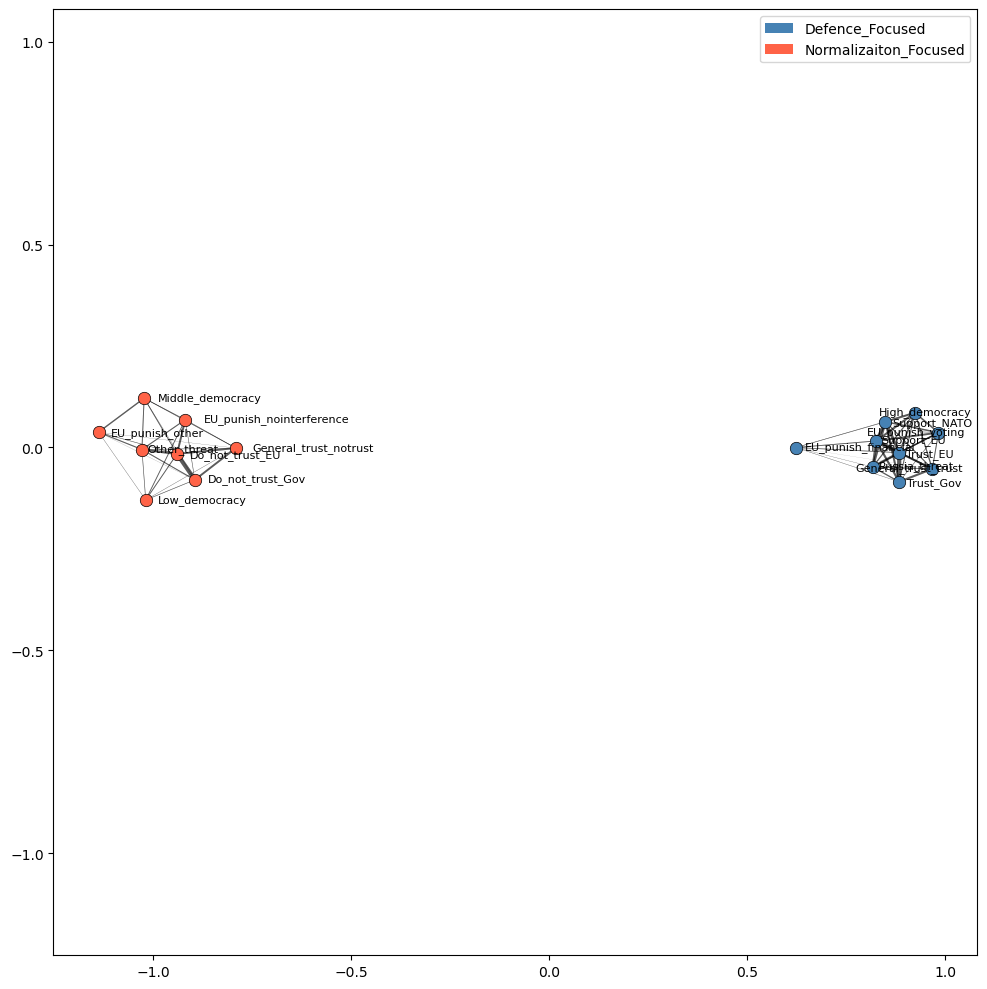

In [40]:
# ── 0. Setup ──────────────────────────────────────────────────────────────
fa_nodes  = ['Defence_Focused', 'Normalizaiton_Focused']
fa_colors = {
    'Defence_Focused':       'steelblue',
    'Normalizaiton_Focused': 'tomato'
}

# ── 1. Build graph (FA nodes excluded) ────────────────────────────────────
list_of_nodes = [c for c in df2_2025.columns if c not in fa_nodes and c != 'Unnamed: 0']
G = make_graph_(df2_2025, list_of_nodes, pears_pos, exclude_same_question=True)

# ── 2. Layout + PCA ───────────────────────────────────────────────────────
pos = nx.spring_layout(G, iterations=50000*10, seed=1998)

pos3     = []
key_list = []
for key in pos:
    pos3.append([pos[key][0], pos[key][1]])
    key_list.append(key)

pca   = PCA(n_components=2)
x_pca = pca.fit_transform(pos3)
xx    = x_pca[:, 0]
yy    = x_pca[:, 1]
mm    = min(xx) * 1.1
MM    = max(xx) * 1.1

# ── 3. FA node attributes + colours ───────────────────────────────────────
for fa in fa_nodes:
    dic_ = {node: pearsonr(df2_2025[node], df2_2025[fa])[0] for node in G.nodes}
    nx.set_node_attributes(G, dic_, fa)

nx.write_gexf(G,'data_clean/vertical_extension_network_2025.gexf')

node_colors = {}
for node in G.nodes:
    correlations = {fa: pearsonr(df2_2025[node], df2_2025[fa])[0] for fa in fa_nodes}
    dominant_fa  = max(correlations, key=correlations.get)
    node_colors[node] = fa_colors[dominant_fa]

# ── 4. Plot ───────────────────────────────────────────────────────────────
koef = 3
plt.figure(figsize=(10, 10))

# Edges
weights = [d['weight'] for u, v, d in G.edges(data=True) if d['weight'] > 0]
w_min, w_max = min(weights), max(weights)

for i1, key1 in enumerate(key_list):
    for i2, key2 in enumerate(key_list):
        if (key1, key2) in G.edges:
            w = G.get_edge_data(key1, key2)['weight']
            if w > 0.:
                w_scaled = (w - w_min) / (w_max - w_min)
                plt.plot(
                    [xx[i1], xx[i2]], [yy[i1], yy[i2]],
                    color='k', linewidth=koef * w_scaled,
                    alpha=0.4, zorder=1
                )

# Nodes + labels
texts = []
for i, key in enumerate(key_list):
    plt.scatter(xx[i], yy[i], s=80,
                c=node_colors[key], zorder=2,
                edgecolors='k', linewidths=0.5)
    texts.append(plt.text(xx[i], yy[i], key, fontsize=8))

adjust_text(texts, arrowprops=dict(arrowstyle='-', color='gray', lw=0.5))

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=fa) for fa, c in fa_colors.items()]
plt.legend(handles=legend_elements, loc='best')

plt.xlim([mm, MM])
plt.ylim([mm, MM])
plt.tight_layout()
plt.show()